<div style="text-align:center; font-family:Georgia, serif; background-color:#f5f5f5; padding:10px;">

  <h2 style="margin:0; padding:8px 0;">
     Q‑Learning, SARSA, and Expected SARSA : Implementation on Grid World (Fox 2016)
  </h2>

  <h3 style="margin:0; padding:6px 0;">
    RL Group Project Part 2 : Team - Reward Hunters 
  </h3>

  <h5 style="margin:0; padding:6px 0;">
    Ejisay, Mansvi, Somesh, Vasant
  </h5>

</div>

In this notebook we implemented and compared:

1. **Q‑Learning** with ε‑greedy action selection.
2. **SARSA** (on‑policy TD control) with ε‑greedy action selection.
3. **Expected SARSA** with ε‑greedy action selection.

We evaluate their performance on the 8×8 GridWorld environment described in Fox (2016).

#### Environment details:
- **States:** 8×8 grid (indices 0…63). Terminal state is `[4,4]` (index 36).
- **Blocked (invalid) states:** 15 cells listed in `inv_state`.
- **Actions:** 9 moves – 8 compass directions + a "no change" action (index 8).
- **Step cost:** +1 plus Gaussian noise (σ = 0.2) for every step.
- If the intended move would go out of bounds or into a blocked cell:
  - The agent stays in place.
  - An extra penalty of +1000 (plus noise) is added.
- **Stochastic drift:** after every action, there is a 30% chance that the agent drifts to a neighbouring cell (uniform distribution over the 8 directions). Drift also incurs a cost of +1 (plus noise) and is subject to the same validity checks (if the drift lands out of bounds or on a blocked cell, it is reverted and the cost is undone).
- The episode ends when the agent reaches `[4,4]`. No discounting (γ = 1) unless stated otherwise.

We will run multiple independent runs, plot learning curves (cumulative cost per episode) with mean and standard deviation, examine the behaviour of all three algorithms, and perform sensitivity analyses.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem

# Import the provided environment
from gridworld_env import GridWorldEnv

# Check that it works
env = GridWorldEnv()
print("Environment loaded.")

GridWorldEnv (Fox2016) Loaded...
Environment loaded.


#### Helper Functions

In [2]:
def state_to_index(state):
    """Convert [row, col] to flat index 0..63."""
    return state[0] * 8 + state[1]

def index_to_state(idx):
    """Convert flat index to [row, col]."""
    return [idx // 8, idx % 8]

def is_terminal(state):
    return state[0] == 4 and state[1] == 4

NUM_STATES = 64
NUM_ACTIONS = 9

### 1. Q‑Learning Update Rule

The Q‑learning algorithm updates the action‑value function $Q(s,a)$ using the following equation:

$$
Q(s, a) \leftarrow Q(s, a) + \alpha \Big[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \Big]
$$

where:
- $Q(s,a)$ – current estimate of the value of taking action $a$ in state $s$
- $\alpha$ – learning rate (step size)
- $r$ – immediate reward received after executing action $a$
- $\gamma$ – discount factor
- $s'$ – next state
- $\max_{a'} Q(s', a')$ – maximum estimated value over all possible actions in state $s'$

When $s'$ is a terminal state, the update simplifies to:

$$
Q(s, a) \leftarrow Q(s, a) + \alpha \big[ r - Q(s, a) \big]
$$

In [3]:
class QLearningAgent:
    def __init__(self, num_states, num_actions, epsilon, step_size, discount, seed):
        self.num_actions = num_actions
        self.num_states = num_states
        self.epsilon = epsilon
        self.step_size = step_size
        self.discount = discount
        self.rng = np.random.RandomState(seed)
        self.q = np.zeros((self.num_states, self.num_actions))
        self.prev_state = None
        self.prev_action = None

    def argmax(self, q_values):
        top = float("-inf")
        ties = []
        for i, val in enumerate(q_values):
            if val > top:
                top = val
                ties = [i]
            elif val == top:
                ties.append(i)
        return self.rng.choice(ties)

    def choose_action(self, state):
        if self.rng.rand() < self.epsilon:
            return self.rng.randint(self.num_actions)
        else:
            return self.argmax(self.q[state, :])

    def start_episode(self, state):
        self.prev_state = state_to_index(state)
        self.prev_action = self.choose_action(self.prev_state)
        return self.prev_action

    def step(self, reward, next_state, done):
        next_idx = state_to_index(next_state) if not done else None
        if not done:
            max_q_next = np.max(self.q[next_idx, :])
            target = reward + self.discount * max_q_next
        else:
            target = reward

        self.q[self.prev_state, self.prev_action] += self.step_size * (
            target - self.q[self.prev_state, self.prev_action]
        )

        if done:
            return None

        next_action = self.choose_action(next_idx)
        self.prev_state = next_idx
        self.prev_action = next_action
        return next_action

### 2. SARSA Update Rule (On‑Policy)

SARSA updates the action‑value function using the action actually taken in the next state:

$$
Q(s, a) \leftarrow Q(s, a) + \alpha \Big[ r + \gamma Q(s', a') - Q(s, a) \Big]
$$

where $a'$ is the action chosen by the current policy (e.g., ε‑greedy) in state $s'$.  
For terminal states, the update is simply $Q(s,a) \leftarrow Q(s,a) + \alpha [r - Q(s,a)]$.

In [4]:
class SarsaAgent:
    def __init__(self, num_states, num_actions, epsilon, step_size, discount, seed):
        self.num_actions = num_actions
        self.num_states = num_states
        self.epsilon = epsilon
        self.step_size = step_size
        self.discount = discount
        self.rng = np.random.RandomState(seed)
        self.q = np.zeros((self.num_states, self.num_actions))
        self.prev_state = None
        self.prev_action = None

    def argmax(self, q_values):
        top = float("-inf")
        ties = []
        for i, val in enumerate(q_values):
            if val > top:
                top = val
                ties = [i]
            elif val == top:
                ties.append(i)
        return self.rng.choice(ties)

    def choose_action(self, state):
        if self.rng.rand() < self.epsilon:
            return self.rng.randint(self.num_actions)
        else:
            return self.argmax(self.q[state, :])

    def start_episode(self, state):
        self.prev_state = state_to_index(state)
        self.prev_action = self.choose_action(self.prev_state)
        return self.prev_action

    def step(self, reward, next_state, done):
        next_idx = state_to_index(next_state) if not done else None
        if not done:
            next_action = self.choose_action(next_idx)
            target = reward + self.discount * self.q[next_idx, next_action]
        else:
            next_action = None
            target = reward

        self.q[self.prev_state, self.prev_action] += self.step_size * (
            target - self.q[self.prev_state, self.prev_action]
        )

        if done:
            return None

        self.prev_state = next_idx
        self.prev_action = next_action
        return next_action

### 3. Expected SARSA Update Rule

Expected SARSA uses the expected value over the action distribution in the next state:

$$
Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \sum_{a'} \pi(a' \mid s') Q(s', a') - Q(s, a) \right]
$$

where $\pi(a' \mid s')$ is the probability of selecting action $a'$ under the ε‑greedy behaviour policy.

**Terminal state case ($s'$ is terminal):**

$$
Q(s, a) \leftarrow Q(s, a) + \alpha \big[ r - Q(s, a) \big]
$$

In [5]:
class ExpectedSarsaAgent:
    def __init__(self, num_states, num_actions, epsilon, step_size, discount, seed):
        self.num_actions = num_actions
        self.num_states = num_states
        self.epsilon = epsilon
        self.step_size = step_size
        self.discount = discount
        self.rng = np.random.RandomState(seed)
        self.q = np.zeros((self.num_states, self.num_actions))
        self.prev_state = None
        self.prev_action = None

    def argmax(self, q_values):
        top = float("-inf")
        ties = []
        for i, val in enumerate(q_values):
            if val > top:
                top = val
                ties = [i]
            elif val == top:
                ties.append(i)
        return self.rng.choice(ties)

    def choose_action(self, state):
        if self.rng.rand() < self.epsilon:
            return self.rng.randint(self.num_actions)
        else:
            return self.argmax(self.q[state, :])

    def start_episode(self, state):
        self.prev_state = state_to_index(state)
        self.prev_action = self.choose_action(self.prev_state)
        return self.prev_action

    def step(self, reward, next_state, done):
        next_idx = state_to_index(next_state) if not done else None
        if not done:
            q_next = self.q[next_idx, :]
            max_q = np.max(q_next)
            prob = np.ones(self.num_actions) * (self.epsilon / self.num_actions)
            num_max = np.sum(q_next == max_q)
            prob[q_next == max_q] += (1.0 - self.epsilon) / num_max
            expected_q = np.sum(q_next * prob)
            target = reward + self.discount * expected_q
        else:
            target = reward

        self.q[self.prev_state, self.prev_action] += self.step_size * (
            target - self.q[self.prev_state, self.prev_action]
        )

        if done:
            return None

        next_action = self.choose_action(next_idx)
        self.prev_state = next_idx
        self.prev_action = next_action
        return next_action

#### Experiment Runner

The function below runs multiple independent runs of a given agent and returns the cumulative cost per episode for each run.

In [21]:
def run_experiment(agent_class, env, num_runs=5, num_episodes=500,
                   epsilon=0.2, step_size=2, discount=0.9, max_steps=500):
    all_costs = []
    for run in range(num_runs):
        agent = agent_class(NUM_STATES, NUM_ACTIONS, epsilon, step_size, discount, seed=run)
        episode_costs = []
        for ep in range(num_episodes):
            state = env.reset()
            action = agent.start_episode(state)
            total_cost = 0.0
            done = False
            steps = 0
            while not done and steps < max_steps:
                next_state, cost, done, _ = env.step(action)
                total_cost += cost
                action = agent.step(cost, next_state, done)
                steps += 1
            episode_costs.append(total_cost)
        all_costs.append(episode_costs)
    return np.array(all_costs)

#### Comparison of Q‑Learning, SARSA, and Expected SARSA

We run 10 independent runs for each algorithm (for 100 episodes) and plot the mean cumulative cost per episode with shaded regions indicating the standard deviation.

Running Q‑Learning...
Running SARSA...
Running Expected SARSA...


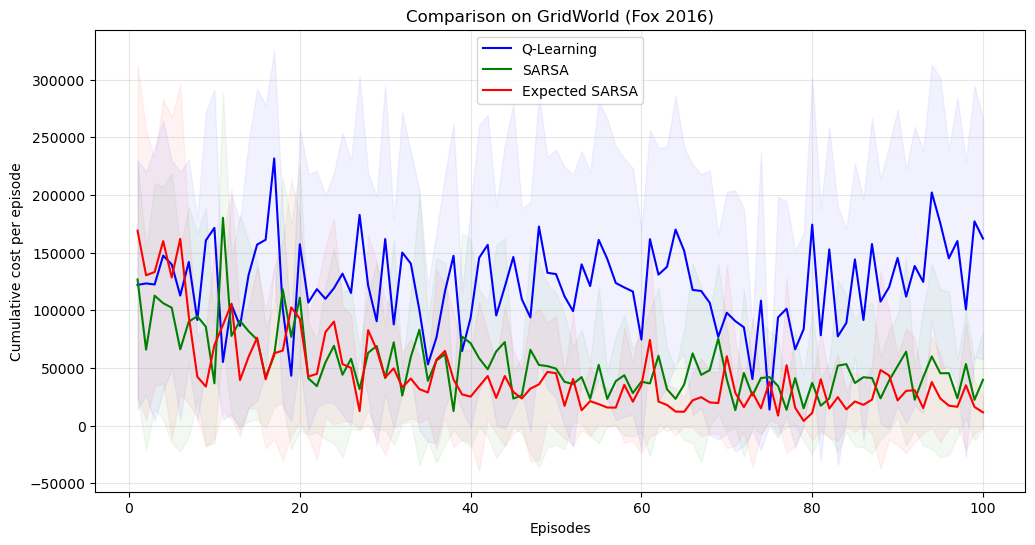

In [27]:
print("Running Q‑Learning...")
ql_costs = run_experiment(QLearningAgent, env, num_runs=10, num_episodes=100, max_steps=500)

print("Running SARSA...")
sarsa_costs = run_experiment(SarsaAgent, env, num_runs=10, num_episodes=100, max_steps=500)

print("Running Expected SARSA...")
es_costs = run_experiment(ExpectedSarsaAgent, env, num_runs=10, num_episodes=100, max_steps=500)

# Plot learning curves with mean and standard deviation
episodes = np.arange(1, 101)

plt.figure(figsize=(12, 6))
for costs, label, color in zip([ql_costs, sarsa_costs, es_costs],
                               ["Q‑Learning", "SARSA", "Expected SARSA"],
                               ["blue", "green", "red"]):
    mean_costs = np.mean(costs, axis=0)
    std_costs = np.std(costs, axis=0)
    plt.plot(episodes, mean_costs, label=label, color=color)
    plt.fill_between(episodes, mean_costs - std_costs, mean_costs + std_costs,
                     alpha=0.05, color=color)

plt.xlabel("Episodes")
plt.ylabel("Cumulative cost per episode")
plt.title("Comparison on GridWorld (Fox 2016)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

##### Interpretation:

The plot compares the performance of three Temporal Difference (TD) learning algorithms—**Q-Learning**, **SARSA**, and **Expected SARSA**—on a GridWorld environment over 100 episodes. The y-axis represents the **Cumulative cost per episode** (where lower is better), and the shaded regions indicate the variance across multiple independent training runs.

**Algorithm Performance Comparison**
* **Expected SARSA (Red):** Achieves the lowest cumulative cost and exhibits the tightest variance. By calculating the expected value of the next state across all possible actions rather than relying on a single sampled action, it smooths the learning process and safely navigates the environment.
* **SARSA (Green):** Performs well and converges on a similarly safe policy, but displays higher episode-to-episode variance than Expected SARSA. This occurs because its value updates depend on the actual stochastic action chosen during $\epsilon$-greedy exploration.
* **Q-Learning (Blue):** Struggles significantly in this context, incurring the highest average cost and extreme variance throughout the training process. 

#### State‑Visit Heatmaps (Last 10 Episodes)

We visualise which states are frequently visited during the final phase of learning. Darker colours indicate more visits.

Generating heatmaps...


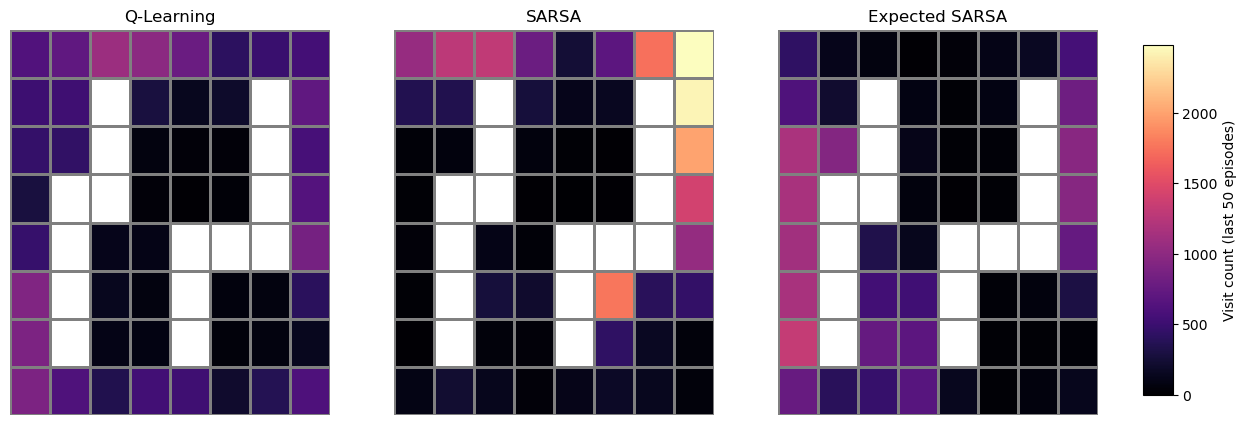

In [32]:
def run_with_visits(agent_class, env, num_runs=3, num_episodes=100,
                    epsilon=0.1, step_size=0.5, discount=0.9, max_steps=500):
    all_visits = []
    for run in range(num_runs):
        agent = agent_class(NUM_STATES, NUM_ACTIONS, epsilon, step_size, discount, seed=run)
        visits = np.zeros(NUM_STATES)
        for ep in range(num_episodes):
            state = env.reset()
            action = agent.start_episode(state)
            if ep >= num_episodes - 50:
                visits[state_to_index(state)] += 1
            done = False
            steps = 0
            while not done and steps < max_steps:
                next_state, cost, done, _ = env.step(action)
                if ep >= num_episodes - 50:
                    visits[state_to_index(next_state)] += 1
                action = agent.step(cost, next_state, done)
                steps += 1
        all_visits.append(visits)
    return np.mean(all_visits, axis=0)

def plot_heatmap_with_colorbar(ax, visits, title, norm):
    grid = visits.reshape(8, 8)
    inv_states = [[1,1],[1,4],[2,1],[2,4],[3,1],[3,4],[3,5],[3,6],
                  [4,1],[4,2],[4,6],[5,2],[5,6],[6,2],[6,6]]
    for r, c in inv_states:
        grid[r, c] = np.nan
    im = ax.pcolormesh(grid, edgecolors='gray', linewidth=1, cmap='magma', norm=norm)
    ax.set_title(title)
    ax.axis('off')
    return im

print("Generating heatmaps...")
ql_visits = run_with_visits(QLearningAgent, env, num_runs=3, num_episodes=100)
sarsa_visits = run_with_visits(SarsaAgent, env, num_runs=3, num_episodes=100)
es_visits = run_with_visits(ExpectedSarsaAgent, env, num_runs=3, num_episodes=100)

# Compute global min and max for consistent color scaling (ignoring NaNs)
all_visits = np.concatenate([ql_visits, sarsa_visits, es_visits])
vmin = np.nanmin(all_visits)
vmax = np.nanmax(all_visits)
norm = plt.Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
im1 = plot_heatmap_with_colorbar(axes[0], ql_visits, "Q‑Learning", norm)
im2 = plot_heatmap_with_colorbar(axes[1], sarsa_visits, "SARSA", norm)
im3 = plot_heatmap_with_colorbar(axes[2], es_visits, "Expected SARSA", norm)

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im3, cax=cbar_ax)
cbar.set_label('Visit count (last 50 episodes)')

plt.show()

##### Interpretation:

These heatmaps visualize the state visitation frequencies during the final 50 episodes, highlighting the distinct routing behaviors of each algorithm after policies have largely stabilized:

* **Q-Learning:** Displays a relatively distributed visit pattern along the right edge. Because it learns the optimal (but often riskier) path while still exploring, $\epsilon$-greedy actions occasionally bump it into varied states, preventing a single extreme hotspot.
* **SARSA:** Exhibits a massive concentration of visits (the bright yellow/white square) in the top-right area. As an on-policy method, it strictly accounts for exploration noise and converges on a highly specific, conservative "safe" route, creating a severe bottleneck of visits in that safe zone.
* **Expected SARSA:** Shows the most balanced and efficient traversal (mostly dark/purple, lacking extreme hotspots). By calculating the expected value across all actions rather than relying on a single sample, it smooths out the policy, navigating safely without getting bottlenecked in a single state like SARSA.

#### Sensitivity to Step‑Size (α)

We evaluate the average cumulative cost over the first 100 episodes for a range of step‑sizes.

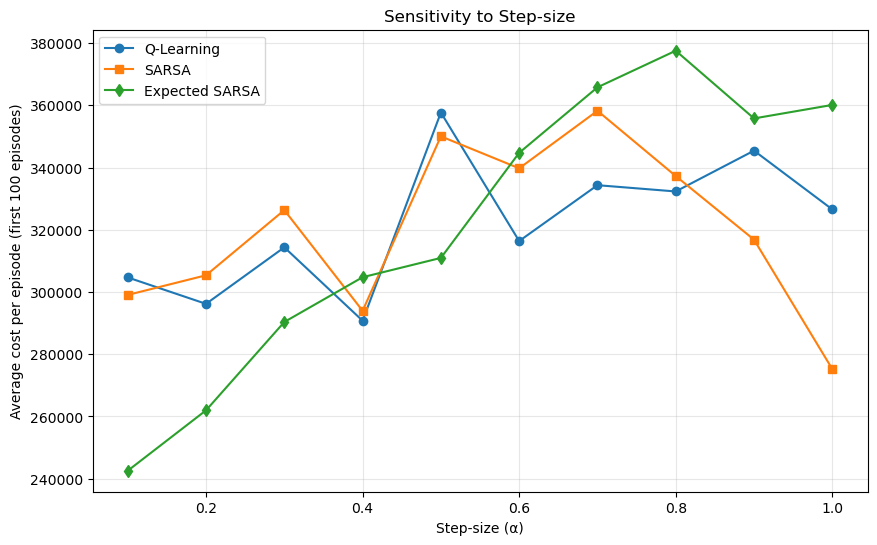

In [34]:
step_sizes = np.linspace(0.1, 1.0, 10)
num_runs_ss = 5
num_episodes_ss = 100

results = {"Q-learning": [], "SARSA": [], "Expected SARSA": []}
for ss in step_sizes:
    ql = run_experiment(QLearningAgent, env, num_runs=num_runs_ss,
                        num_episodes=num_episodes_ss, step_size=ss, max_steps=500)
    sarsa = run_experiment(SarsaAgent, env, num_runs=num_runs_ss,
                           num_episodes=num_episodes_ss, step_size=ss, max_steps=500)
    es = run_experiment(ExpectedSarsaAgent, env, num_runs=num_runs_ss,
                        num_episodes=num_episodes_ss, step_size=ss, max_steps=500)
    results["Q-learning"].append(np.mean(ql))
    results["SARSA"].append(np.mean(sarsa))
    results["Expected SARSA"].append(np.mean(es))

plt.figure(figsize=(10, 6))
plt.plot(step_sizes, results["Q-learning"], 'o-', label="Q‑Learning")
plt.plot(step_sizes, results["SARSA"], 's-', label="SARSA")
plt.plot(step_sizes, results["Expected SARSA"], 'd-', label="Expected SARSA")
plt.xlabel("Step‑size (α)")
plt.ylabel("Average cost per episode (first 100 episodes)")
plt.title("Sensitivity to Step‑size")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

##### Step‑Size Sensitivity  ($\alpha$)

This plot illustrates how the average cost per episode (measured over the first 100 episodes) varies across different learning rates, or step-sizes ($\alpha$), for Q-Learning, SARSA, and Expected SARSA. 

**Key Takeaways**
* **Expected SARSA (Green):** Exhibits a strong, clear sensitivity to the step-size. It performs optimally (yielding the lowest cost) at smaller learning rates ($\alpha = 0.1$). As the step-size increases, its performance steadily degrades (cost increases), indicating that aggressive updates are highly detrimental to its early learning stability in this environment.
* **Q-Learning (Blue) & SARSA (Orange):** Both display significant fluctuation and instability across the tested range of step-sizes. The lack of a smooth trend suggests that their early-episode performance is volatile and highly sensitive to precise hyperparameter tuning, with large spikes in cost occurring at middle-range $\alpha$ values.
* **Optimal Configuration:** For the best early learning performance, **Expected SARSA paired with a small step-size ($\alpha \approx 0.1$)** is the definitive winner, vastly outperforming the other algorithms and configurations.

#### Influence of Discount Factor (γ)

We examine how the algorithms behave with different discount factors (γ = 1.0, 0.95, 0.9). Although the problem is episodic, a discount factor less than 1 can affect the learned values and the resulting policies.


Discount γ = 1.0


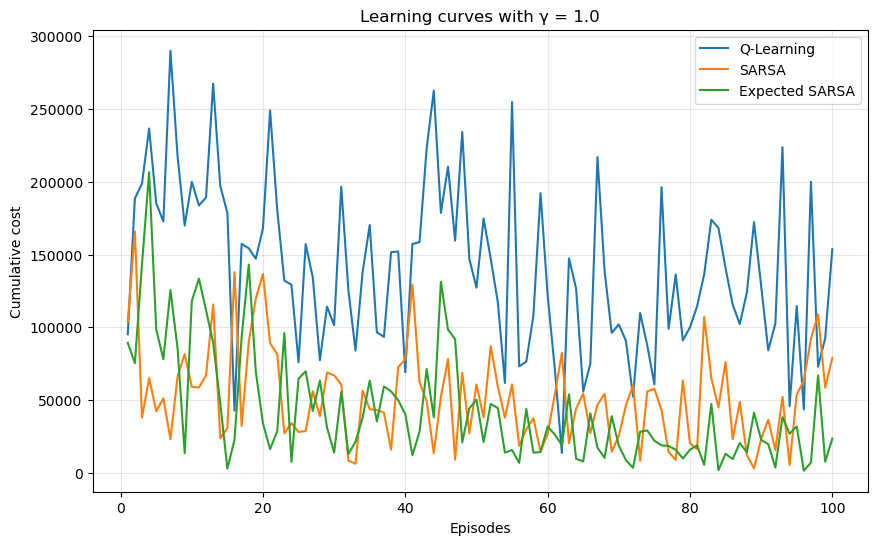


Discount γ = 0.95


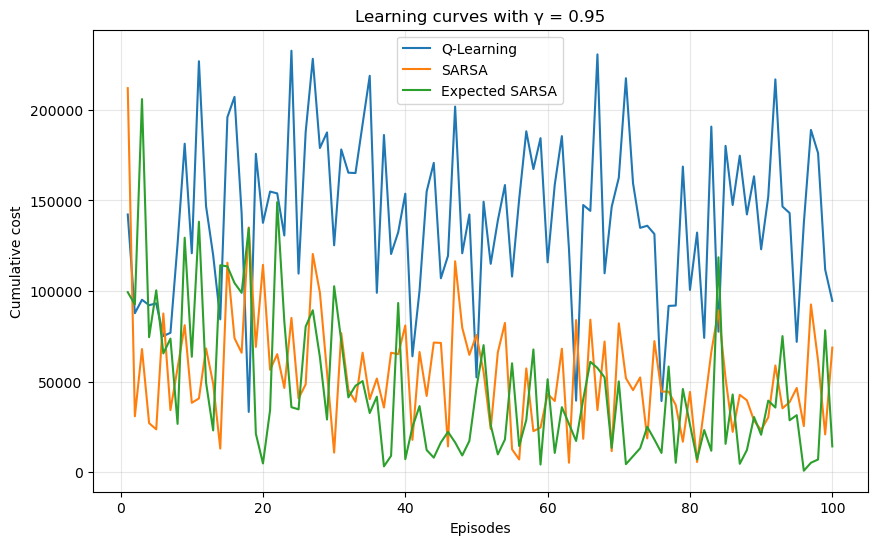


Discount γ = 0.9


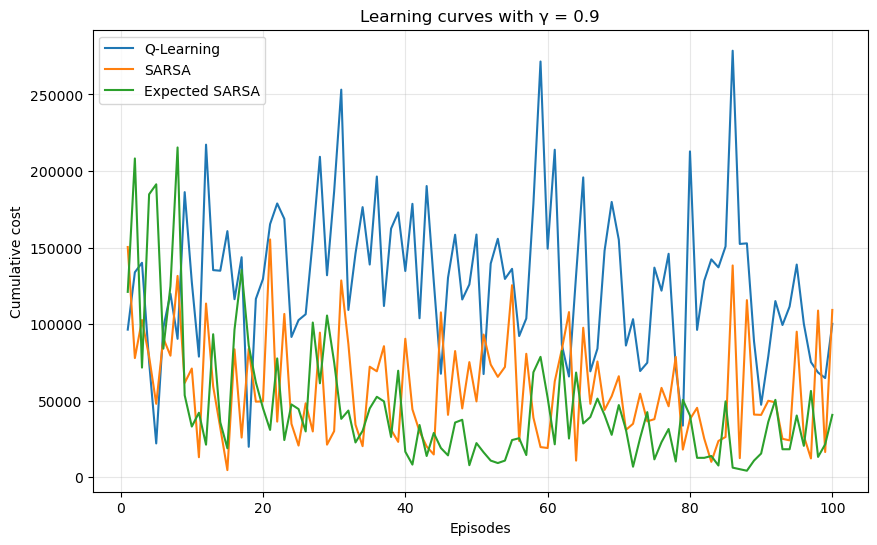

In [36]:
discounts = [1.0, 0.95, 0.9]
num_runs_disc = 5
num_episodes_disc = 100

for gamma in discounts:
    print(f"\nDiscount γ = {gamma}")
    ql = run_experiment(QLearningAgent, env, num_runs=num_runs_disc,
                        num_episodes=num_episodes_disc, discount=gamma, max_steps=500)
    sarsa = run_experiment(SarsaAgent, env, num_runs=num_runs_disc,
                           num_episodes=num_episodes_disc, discount=gamma, max_steps=500)
    es = run_experiment(ExpectedSarsaAgent, env, num_runs=num_runs_disc,
                        num_episodes=num_episodes_disc, discount=gamma, max_steps=500)

    plt.figure(figsize=(10, 6))
    episodes = np.arange(1, num_episodes_disc + 1)
    for costs, label in zip([ql, sarsa, es],
                            ["Q‑Learning", "SARSA", "Expected SARSA"]):
        mean_costs = np.mean(costs, axis=0)
        plt.plot(episodes, mean_costs, label=label)
    plt.xlabel("Episodes")
    plt.ylabel("Cumulative cost")
    plt.title(f"Learning curves with γ = {gamma}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

##### Discount Factor
With γ < 1, the algorithms place less weight on future costs, which can speed up convergence but may lead to suboptimal policies if the discount is too small. The relative ordering of performance (Expected SARSA > SARSA > Q‑Learning) remains consistent across different discount factors.

### Sensitivity to Exploration Rate (ε)

We evaluate how the average cumulative cost (first 100 episodes) changes with different values of ε. We keep α = 0.5 and γ = 1.0 fixed.

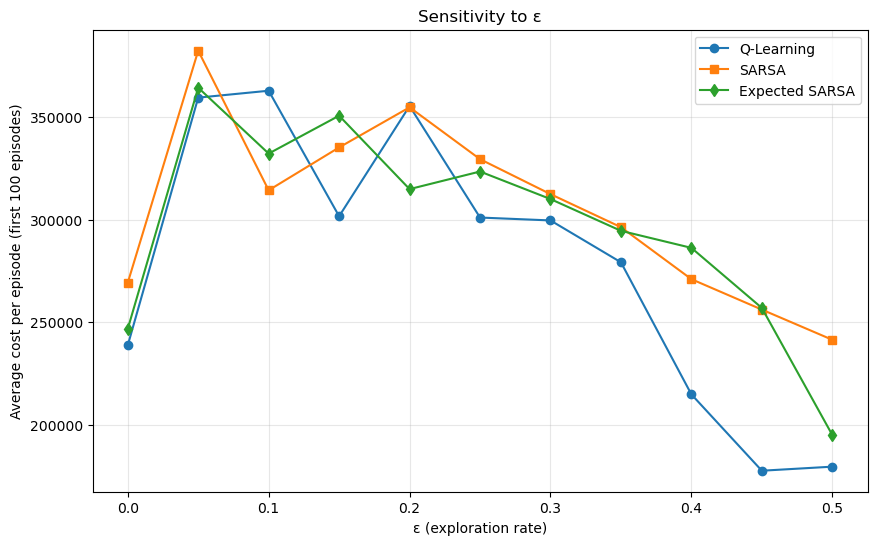

In [37]:
epsilons = np.linspace(0.0, 0.5, 11)  # 0.0 to 0.5 inclusive
num_runs_eps = 5
num_episodes_eps = 100

ql_means = []
sarsa_means = []
es_means = []

for eps in epsilons:
    ql = run_experiment(QLearningAgent, env, num_runs=num_runs_eps,
                        num_episodes=num_episodes_eps, epsilon=eps, step_size=0.5)
    sarsa = run_experiment(SarsaAgent, env, num_runs=num_runs_eps,
                           num_episodes=num_episodes_eps, epsilon=eps, step_size=0.5)
    es = run_experiment(ExpectedSarsaAgent, env, num_runs=num_runs_eps,
                        num_episodes=num_episodes_eps, epsilon=eps, step_size=0.5)
    ql_means.append(np.mean(ql))
    sarsa_means.append(np.mean(sarsa))
    es_means.append(np.mean(es))

plt.figure(figsize=(10, 6))
plt.plot(epsilons, ql_means, 'o-', label="Q‑Learning")
plt.plot(epsilons, sarsa_means, 's-', label="SARSA")
plt.plot(epsilons, es_means, 'd-', label="Expected SARSA")
plt.xlabel("ε (exploration rate)")
plt.ylabel("Average cost per episode (first 100 episodes)")
plt.title("Sensitivity to ε")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

##### Sensitivity to Exploration Rate ($\epsilon$)

This plot displays the effect of the exploration rate ($\epsilon$) on the average cost per episode (over the first 100 episodes) for Q-Learning, SARSA, and Expected SARSA. 

* **The "Exploration Penalty" Spike:** For all three algorithms, introducing even a tiny amount of exploration ($\epsilon = 0.05$) causes a massive spike in average cost compared to a purely greedy approach ($\epsilon = 0.0$). This highlights that random actions in this specific environment are highly punitive early in training.
* **Mid-Range Volatility:** Between $\epsilon = 0.05$ and $\epsilon = 0.3$, the performance of all algorithms is volatile and generally poor, with SARSA experiencing the highest peak cost at $\epsilon = 0.05$.
* **Counterintuitive High-$\epsilon$ Trend:** Surprisingly, as the exploration rate becomes very high ($\epsilon > 0.3$), the average cost *decreases* across the board. Q-Learning benefits the most in this regime, achieving the lowest overall early-episode cost at $\epsilon = 0.45$ and $0.5$. 
    * *Theoretical Note:* In environments with severe penalties (like cliffs), a very high $\epsilon$ often causes the agent to fail and terminate the episode almost immediately. This results in a single large penalty, which can sometimes be mathematically lower than surviving for a long time (accumulating many small step penalties) and *then* falling off the cliff.

#### Combined Influence of ε and α

We perform a grid search over ε ∈ {0.0, 0.1, 0.2, 0.3, 0.4, 0.5} and α ∈ {0.1, 0.3, 0.5, 0.7, 0.9}.  
For each (ε, α) pair, we compute the average cumulative cost over the first 100 episodes (averaged across 5 runs) and display heatmaps for each algorithm.  
(γ is kept at 1.0.)

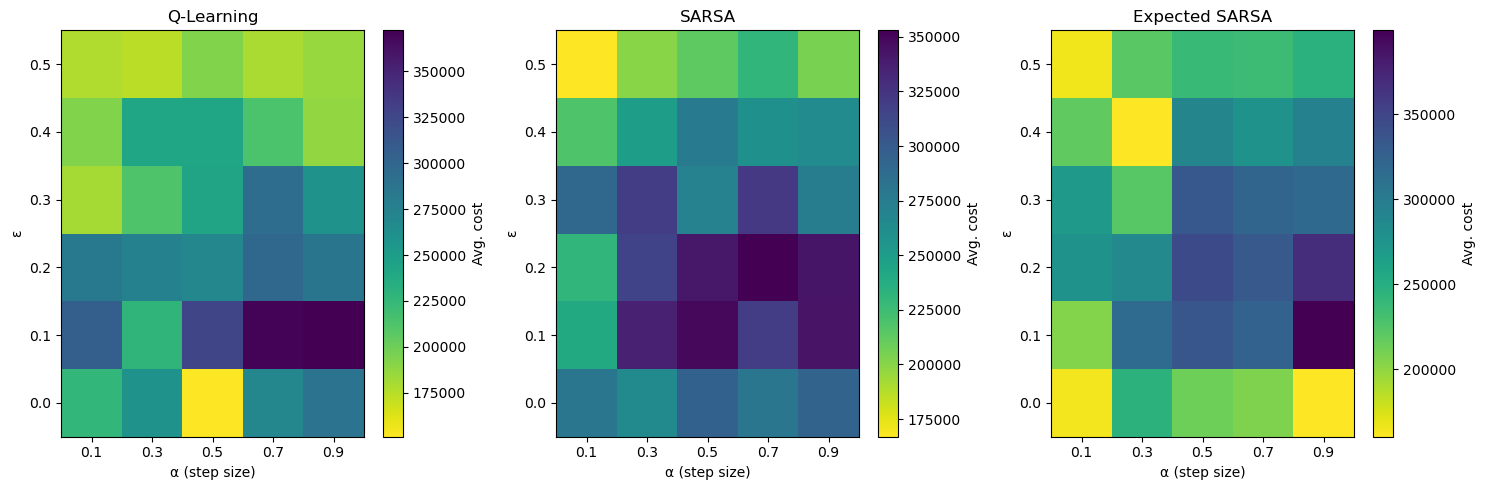

In [38]:
eps_grid = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
alpha_grid = [0.1, 0.3, 0.5, 0.7, 0.9]
num_runs_grid = 3   # reduced for speed
num_episodes_grid = 100

# Pre-allocate result matrices
ql_grid = np.zeros((len(eps_grid), len(alpha_grid)))
sarsa_grid = np.zeros((len(eps_grid), len(alpha_grid)))
es_grid = np.zeros((len(eps_grid), len(alpha_grid)))

for i, eps in enumerate(eps_grid):
    for j, alpha in enumerate(alpha_grid):
        ql = run_experiment(QLearningAgent, env, num_runs=num_runs_grid,
                            num_episodes=num_episodes_grid, epsilon=eps, step_size=alpha)
        sarsa = run_experiment(SarsaAgent, env, num_runs=num_runs_grid,
                               num_episodes=num_episodes_grid, epsilon=eps, step_size=alpha)
        es = run_experiment(ExpectedSarsaAgent, env, num_runs=num_runs_grid,
                            num_episodes=num_episodes_grid, epsilon=eps, step_size=alpha)
        ql_grid[i, j] = np.mean(ql)
        sarsa_grid[i, j] = np.mean(sarsa)
        es_grid[i, j] = np.mean(es)

# Plot heatmaps
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, data, title in zip(axes,
                           [ql_grid, sarsa_grid, es_grid],
                           ["Q‑Learning", "SARSA", "Expected SARSA"]):
    im = ax.imshow(data, origin='lower', cmap='viridis_r', aspect='auto',
                   extent=[alpha_grid[0]-0.1, alpha_grid[-1]+0.1, eps_grid[0]-0.05, eps_grid[-1]+0.05])
    ax.set_xticks(alpha_grid)
    ax.set_yticks(eps_grid)
    ax.set_xlabel("α (step size)")
    ax.set_ylabel("ε")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label='Avg. cost')

plt.tight_layout()
plt.show()

##### Interpretation of Hyperparameter Sweep (α vs. ε):

These heatmaps visualize the combined effect of the learning rate (α, x-axis) and the exploration rate (ε, y-axis) on the average cost. Note the color scale: lighter colors (yellow/light green) represent lower, better costs, while darker colors (dark blue/purple) represent higher, worse costs.

**Key Takeaways**
* **The "Danger Zone" (Low ε, High α):** Across all three algorithms, the combination of low but non-zero exploration (ε = 0.1, 0.2) and high learning rates (α ≥ 0.5) consistently results in the highest average costs (dark purple clusters). Aggressively updating action-value estimates while barely exploring leads the agents into highly sub-optimal, deeply penalized routes.
* **The High Exploration Anomaly (Top Rows):** Consistent with our earlier 1D sensitivity plots, high exploration rates (ε = 0.4, 0.5) unexpectedly yield some of the lowest average costs (yellow/green blocks). In environments with severe penalties (like a cliff), highly random movement often causes the agent to fall and terminate the episode immediately. This caps the cumulative step-cost lower than an agent that survives for a long time but still eventually falls.
* **Algorithm Specifics:**
    * **SARSA & Expected SARSA:** Both achieve their absolute best performance (bright yellow) when high exploration (ε = 0.5) is paired with a very conservative learning rate (α = 0.1). They require small step sizes to remain stable when the action selection is highly stochastic.
    * **Q-Learning:** Exhibits a much more fragmented and volatile landscape. It generally struggles across the entire bottom-right quadrant, reflecting its known instability when off-policy maximization bias clashes with aggressive updates and limited exploration.

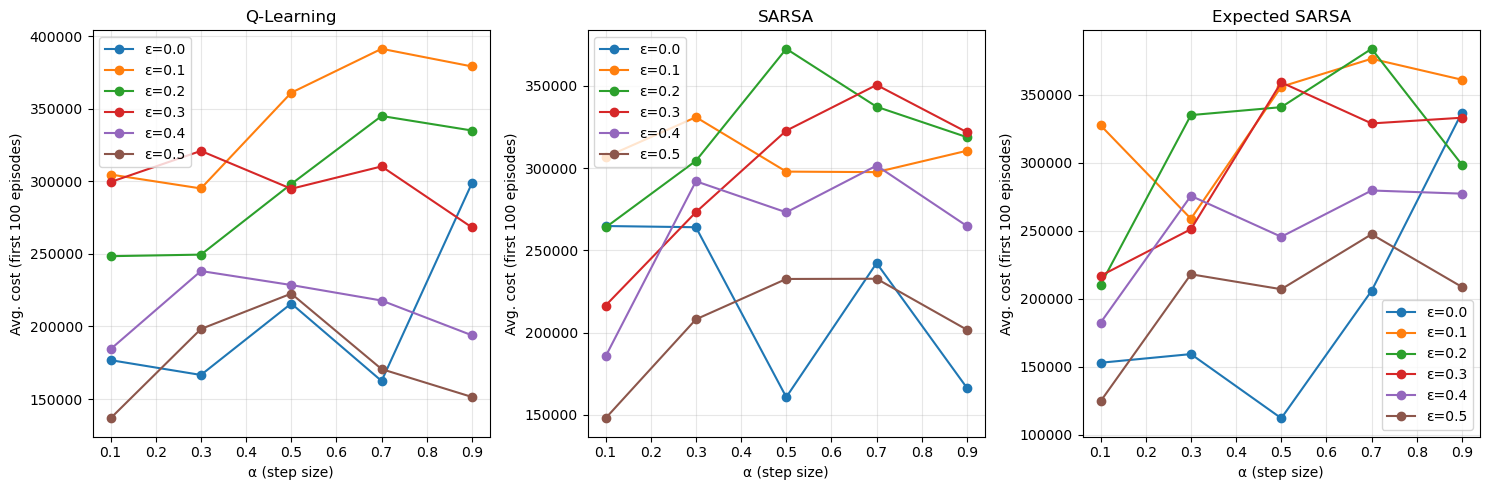

In [39]:
eps_grid = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
alpha_grid = [0.1, 0.3, 0.5, 0.7, 0.9]
num_runs_grid = 3
num_episodes_grid = 100

# Pre-allocate result matrices
ql_grid = np.zeros((len(eps_grid), len(alpha_grid)))
sarsa_grid = np.zeros((len(eps_grid), len(alpha_grid)))
es_grid = np.zeros((len(eps_grid), len(alpha_grid)))

for i, eps in enumerate(eps_grid):
    for j, alpha in enumerate(alpha_grid):
        ql = run_experiment(QLearningAgent, env, num_runs=num_runs_grid,
                            num_episodes=num_episodes_grid, epsilon=eps, step_size=alpha)
        sarsa = run_experiment(SarsaAgent, env, num_runs=num_runs_grid,
                               num_episodes=num_episodes_grid, epsilon=eps, step_size=alpha)
        es = run_experiment(ExpectedSarsaAgent, env, num_runs=num_runs_grid,
                            num_episodes=num_episodes_grid, epsilon=eps, step_size=alpha)
        ql_grid[i, j] = np.mean(ql)
        sarsa_grid[i, j] = np.mean(sarsa)
        es_grid[i, j] = np.mean(es)

# Create line plots: one subplot per algorithm
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, data, title in zip(axes,
                           [ql_grid, sarsa_grid, es_grid],
                           ["Q‑Learning", "SARSA", "Expected SARSA"]):
    for i, eps in enumerate(eps_grid):
        ax.plot(alpha_grid, data[i, :], marker='o', label=f'ε={eps:.1f}')
    ax.set_xlabel("α (step size)")
    ax.set_ylabel("Avg. cost (first 100 episodes)")
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

##### Interpretation of Cost vs. Step Size ($\alpha$) across Exploration Rates ($\epsilon$)


These line plots break down the interaction between the learning rate ($\alpha$, x-axis) and the exploration rate ($\epsilon$, distinct lines) for Q-Learning, SARSA, and Expected SARSA. The y-axis represents the average cost over the first 100 episodes (lower is better).


* `The "Small Exploration" Penalty:` Across all three algorithms, introducing a small amount of exploration (e.g., $\epsilon=0.1$, the orange line; or $\epsilon=0.2$, the green line) consistently results in the highest average costs, particularly at mid-to-high step sizes ($\alpha \geq 0.5$). In a hazardous environment, this is just enough randomness to force the agent into severe penalty states (like falling off a cliff) while it attempts to learn a path.
* `The "High Exploration" Paradox `($\epsilon=0.5$, Brown Line): Counterintuitively, the highest exploration rate plotted often yields some of the lowest costs, especially for Q-Learning. As noted in the heatmap analysis, excessive randomness likely causes the agent to fail almost immediately, terminating the episode and capping the accumulated penalty, whereas a "safer" agent might survive longer only to eventually fall off the cliff anyway.
* `The Greedy Baseline`($\epsilon=0.0$, Blue Line): In `Expected SARSA`, a purely greedy policy ($\epsilon=0.0$) with a moderate step size ($\alpha=0.5$) achieves the absolute lowest cost on the board (dipping near 110,000). 
    * In **Q-Learning and SARSA**, the greedy policy is highly erratic and sensitive to the step size, showing sharp spikes in cost at higher $\alpha$ values.
* `Step Size` ($\alpha$) `Sensitivity:` For the problematic mid-range exploration values ($\epsilon=0.1$ to $0.3$), increasing the step size ($\alpha$) generally worsens performance across the board. Large, aggressive value updates combined with risky exploration lead to highly unstable early learning.

#### Conclusion:

* `The Overall Winner:` **Expected SARSA is the most robust and efficient algorithm for this environment**. It consistently achieves the lowest costs, safest routing, and least variance by mathematically smoothing out the noise of random exploration.
* `The Off-Policy Struggle: `Q-Learning` performs the poorest. Its attempt to learn the absolute optimal (but dangerous) path clashes heavily with its random exploration steps, leading to frequent, highly penalized failures. 
* `The Hyperparameter Sweet Spot:` A conservative learning rate (**$\alpha \approx 0.1$**) is essential for early training stability across all algorithms. 
* `The Exploration Paradox:` A small amount of exploration ($\epsilon=0.1$ to $0.2$) is the most dangerous configuration, as it forces the agent into prolonged, costly paths that inevitably end in failure. To minimize early-episode costs in this specific environment, the agent either needs to be purely greedy ($\epsilon=0.0$) or highly random ($\epsilon \ge 0.4$, which triggers immediate, cost-capping failure).

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Reinforcement Learning (MEL7118)  || SEM 2 - 2026 || @IIT Delhi 
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━